# Evaluation of the Pléiades Neo → Pléiades Degradation Pipeline

**Objective.** Quantitatively assess whether simulated Pléiades images (obtained by degrading Pléiades Neo imagery) are statistically indistinguishable from real Pléiades acquisitions.

**Metrics.** Kernel Inception Distance (KID), Multi-Scale Inception Distance (MSID), Inception Score (IS), Cosine Similarity, and Euclidean Distance — all computed on SatDINO (ViT-Base/16) tile embeddings.

**Datasets.**
- `Neo_*` — Real Pléiades Neo images (baseline / high-resolution source)  
- `simulated_*` — Simulated Pléiades images produced by the degradation pipeline  
- `pl_*` — Real Pléiades images (target distribution)


## 1. Imports & Configuration

In [1]:
# --- Standard library ---
import os
import random
from glob import glob

# --- Numerical & image ---
import numpy as np
import rasterio
from PIL import Image

# --- Deep learning ---
import torch
import torchvision.transforms as T
from ultralytics import YOLO
from transformers import AutoModel
from transformers.modeling_utils import PreTrainedModel

# --- Metrics ---
from piq import KID, MSID, IS
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# --- Dimensionality reduction & geometry ---
import umap
from scipy.spatial import ConvexHull
from shapely.geometry import Polygon

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

### 1.1 Experiment Parameters

In [ ]:
# --- Data paths ---
dir_pln = "/home/thomas/Documents/code/pleiades-boat-detection/data/scoring/diff/PLN"  # Pléiades néo & Simulated
dir_pl  = "/home/thomas/Documents/code/pleiades-boat-detection/data/scoring/diff/PL"   # Real Pléiades

# --- Tiling ---
tile_size   = 128
nb_features = 700

# --- SatDINO backbone ---
SATDINO_MODEL = "strakajk/satdino-vit_base-16"
# Alternatives: strakajk/satdino-vit_small-16 | strakajk/satdino-vit_small-8
FMOW_MEAN = (0.3826, 0.3525, 0.3051)
FMOW_STD  = (0.1598, 0.1474, 0.1384)

# --- KID ---
KID_DEGREE      = 3
KID_GAMMA       = None
KID_COEF0       = 1
KID_VAR_AT_M    = None
KID_AVERAGE     = True
KID_N_SUBSETS   = 50
KID_SUBSET_SIZE = 600
KID_RET_VAR     = True

# --- UMAP ---
UMAP_N_NEIGHBORS = 50
UMAP_MIN_DIST    = 0.1
UMAP_METRIC      = "cosine"
UMAP_RANDOM_STATE = 42

# --- Colour palette (shared across all plots) ---
COLOR_PALETTE = {
    "Real Neo (Baseline)":  "#e74c3c",
    "Real PHR (Target)":    "#3498db",
    "Simulated PHR (Ours)": "#2ecc71",
}
DRAWING_ORDER = ["Real PHR (Target)", "Real Neo (Baseline)", "Simulated PHR (Ours)"]

## 2. Utility Functions

### 2.1 Image I/O & Pre-processing

In [3]:
def read_image(path):
    with rasterio.open(path) as src:
        image = src.read()
    return image[:3].transpose(1, 2, 0)  # (H, W, 3)


def match_histogram(source, target):
    matched = np.zeros_like(source)
    for c in range(source.shape[2]):
        src_band = source[:, :, c].flatten()
        tgt_band = target[:, :, c].flatten()

        src_values, src_counts = np.unique(src_band, return_counts=True)
        tgt_values, tgt_counts = np.unique(tgt_band, return_counts=True)

        src_cdf = np.cumsum(src_counts).astype(np.float64) / src_counts.sum()
        tgt_cdf = np.cumsum(tgt_counts).astype(np.float64) / tgt_counts.sum()

        interp_tgt_values = np.interp(src_cdf, tgt_cdf, tgt_values)
        matched[:, :, c] = np.interp(src_band, src_values, interp_tgt_values).reshape(source[:, :, c].shape)

    return matched.astype(source.dtype)


def percentile_stretch(image, lower=0, upper=99.99):
    stretched = np.zeros_like(image)
    for c in range(image.shape[2]):
        non_zero_pixels = image[:, :, c][image[:, :, c] > 0]
        if len(non_zero_pixels) == 0:
            stretched[:, :, c] = image[:, :, c]
            continue
        p_low, p_high = np.percentile(non_zero_pixels, [lower, upper])
        stretched[:, :, c] = np.clip((image[:, :, c] - p_low) * 255.0 / (p_high - p_low), 0, 255)
    return stretched.astype(np.uint8)

### 2.2 Tile Extraction & Filtering

In [4]:
def delete_non_data(tile, threshold=0.05):
    """Returns True if the tile contains enough valid (non-zero) pixels."""
    no_data_pixels = np.all(tile == 0, axis=-1)
    return np.mean(no_data_pixels) < threshold


def is_single_color(tile, tolerance=5):
    """Returns True if the tile lacks texture (flat ocean, cloud, or padding)."""
    min_vals = np.min(tile, axis=(0, 1)).astype(np.int16)
    max_vals = np.max(tile, axis=(0, 1)).astype(np.int16)
    return np.all((max_vals - min_vals) < tolerance)


def cut_into_tiles(image, tile_size=64):
    tiles = []
    for i in range(0, image.shape[0], tile_size):
        for j in range(0, image.shape[1], tile_size):
            tile = image[i:i+tile_size, j:j+tile_size, :]
            if tile.shape[0] == tile_size and tile.shape[1] == tile_size:
                if delete_non_data(tile) and not is_single_color(tile):
                    tiles.append(tile)
    print(f"  {len(tiles)} valid tiles of size {tile_size}×{tile_size}")
    return np.array(tiles)

### 2.3 Visualisation Helpers

In [5]:
def plot_matrix(matrix, labels, title="", precision=2):
    plt.figure(figsize=(14, 10))
    plt.imshow(matrix, cmap="viridis", vmin=np.min(matrix), vmax=np.max(matrix))
    plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.yticks(range(len(labels)), labels)
    mean_val = np.mean(matrix)
    for i in range(len(labels)):
        for j in range(len(labels)):
            color = "white" if matrix[i, j] < mean_val else "black"
            plt.text(j, i, f"{matrix[i, j]:.{precision}f}", ha="center", va="center", color=color)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def compute_mean_scores(results, dataset_names, prefix="S2"):
    return {
        name_i: np.mean([results[i, j] for j, name_j in enumerate(dataset_names)
                         if name_j.startswith(prefix) and j != i])
        for i, name_i in enumerate(dataset_names)
    }


def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip("#")
    r, g, b = (int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    return f"rgba({r},{g},{b},{alpha})"

## 3. Feature Extraction — SatDINO

Tile embeddings are extracted using **SatDINO** (ViT-Base/16 pre-trained on fMoW satellite imagery).  
Each tile is normalised with fMoW statistics before being passed through the transformer.  
The CLS token output (768-d) is used as the tile representation.

In [6]:
# Monkey-patch for older transformers compatibility
def _get_all_tied_weights_keys(self):
    val = getattr(self, "_tied_weights_keys", None)
    return val if val is not None else {}
PreTrainedModel.all_tied_weights_keys = property(_get_all_tied_weights_keys)


def build_satdino_transform():
    return T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=FMOW_MEAN, std=FMOW_STD),
    ])


def tile_to_rgb_uint8(tile):
    """(C, H, W) multi-band tile → (H, W, 3) uint8 RGB with percentile stretch."""
    rgb = tile[:3].astype(np.float32) if tile.shape[0] >= 3 else np.stack([tile[0].astype(np.float32)] * 3)

    stretched = np.zeros((3,) + rgb.shape[1:], dtype=np.uint8)
    for c in range(3):
        band = rgb[c]
        p2, p98 = np.percentile(band, 0), np.percentile(band, 100)
        if p98 > p2:
            band = (band - p2) / (p98 - p2)
            # band = band / 255.0
        else:
            band = band - band.min()
            if band.max() > 0:
                band = band / band.max()
        stretched[c] = np.clip(band * 255, 0, 255).astype(np.uint8)
    return np.transpose(stretched, (1, 2, 0))


def extract_satdino_features(tiles, batch_size=32):
    """
    Extract CLS token embeddings from SatDINO.

    Parameters
    ----------
    tiles      : (N, C, H, W) numpy array of multi-band raw tiles
    batch_size : tiles per forward pass

    Returns
    -------
    features   : (N, embed_dim) numpy array — 768-d for ViT-Base
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = AutoModel.from_pretrained(SATDINO_MODEL, trust_remote_code=True).to(device).eval()
    transform = build_satdino_transform()
    all_features = []

    for start in range(0, len(tiles), batch_size):
        batch_tiles = tiles[start:start + batch_size]
        tensors = [transform(Image.fromarray(tile_to_rgb_uint8(t), "RGB")) for t in batch_tiles]
        batch_tensor = torch.stack(tensors).to(device)

        with torch.inference_mode():
            features = model(batch_tensor)

        all_features.append(features.float().cpu().numpy())

    return np.concatenate(all_features, axis=0)


def extract_yolo_features(tiles, model):
    embeddings = []
    for tile in tiles:
        results = model.embed(tile, imgsz=640)
        embeddings.append(results[0].cpu().numpy())
        print(f"  Extracted {len(embeddings)}/{len(tiles)}")
    return embeddings

## 4. Data Loading & Feature Extraction

In [7]:
list_pln = sorted(glob(os.path.join(dir_pln, "**/*.tif"), recursive=True))
list_pl  = sorted(glob(os.path.join(dir_pl,  "**/*.tif"), recursive=True))

print(f"Found {len(list_pln)} Pléiades Neo (PLN) images and {len(list_pl)} Pléiades (PL) images.")

# Tile all images
print("\n— Tiling PLN images —")
pln_tiles = [cut_into_tiles(read_image(path), tile_size) for path in list_pln]

print("\n— Tiling PL images —")
pl_tiles  = [cut_into_tiles(read_image(path), tile_size) for path in list_pl]

Found 6 Pléiades Neo (PLN) images and 6 Pléiades (PL) images.

— Tiling PLN images —
  39707 valid tiles of size 128×128
  3184 valid tiles of size 128×128
  3138 valid tiles of size 128×128
  14252 valid tiles of size 128×128
  4623 valid tiles of size 128×128
  4551 valid tiles of size 128×128

— Tiling PL images —
  52881 valid tiles of size 128×128
  4189 valid tiles of size 128×128
  7125 valid tiles of size 128×128
  81344 valid tiles of size 128×128
  4997 valid tiles of size 128×128
  17686 valid tiles of size 128×128


In [8]:
# Sample random tiles and extract SatDINO embeddings
all_sampled_tiles = []
pln_features = []
pl_features  = []

print("— Extracting PLN features —")
for tiles in pln_tiles:
    random_tiles = random.sample(list(tiles), min(nb_features, len(tiles)))
    all_sampled_tiles.extend(random_tiles)
    pln_features.append(extract_satdino_features(random_tiles, batch_size=64))

print("\n— Extracting PL features —")
for tiles in pl_tiles:
    random_tiles = random.sample(list(tiles), min(nb_features, len(tiles)))
    all_sampled_tiles.extend(random_tiles)
    pl_features.append(extract_satdino_features(random_tiles, batch_size=64))

— Extracting PLN features —


Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

## 5. Dataset Inspection

Sanity-check: visualise a sample tile from each collection.

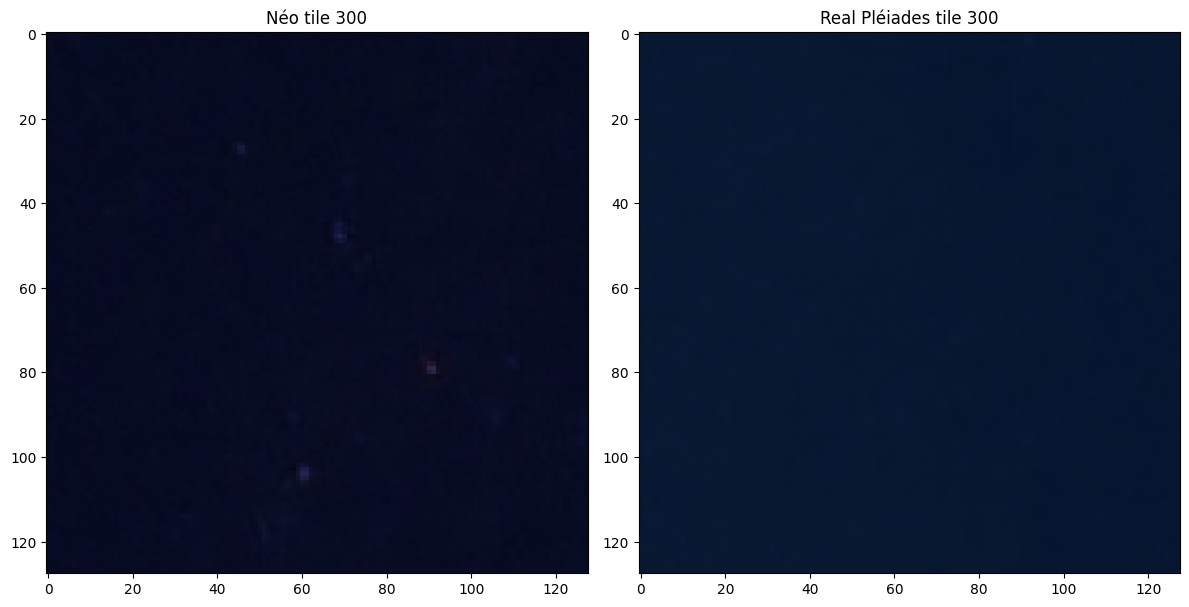

In [9]:
tile_id = 300
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(pln_tiles[0][tile_id])
plt.title(f"Néo tile {tile_id}")
plt.subplot(1, 2, 2)
plt.imshow(pl_tiles[0][tile_id])
plt.title(f"Real Pléiades tile {tile_id}")
plt.tight_layout()
plt.show()

## 6. Dataset Assembly

In [10]:
datasets = {}

for path, feat in zip(list_pln, pln_features):
    base_name = os.path.splitext(os.path.basename(path))[0]
    datasets[base_name] = feat

for i, path in enumerate(list_pl):
    datasets[f"pl_{i}"] = pl_features[i]

dataset_names = list(datasets.keys())
nb_datasets   = len(datasets)

print("Dataset summary:")
for name, feat in datasets.items():
    print(f"  {name:<20s}  {len(feat):>4d} feature vectors")

Dataset summary:
  Neo_1                  700 feature vectors
  Neo_2                  700 feature vectors
  Neo_3                  700 feature vectors
  simulated_1            700 feature vectors
  simulated_2            700 feature vectors
  simulated_3            700 feature vectors
  pl_0                   700 feature vectors
  pl_1                   700 feature vectors
  pl_2                   700 feature vectors
  pl_3                   700 feature vectors
  pl_4                   700 feature vectors
  pl_5                   700 feature vectors


## 7. Kernel Inception Distance (KID)

KID measures the distance between two feature distributions using a polynomial kernel.  
Lower values indicate greater similarity to the target distribution.  
*Parameters:* degree=3, n_subsets=50, subset_size=100.

In [11]:
metric = KID(
    degree=KID_DEGREE,
    gamma=KID_GAMMA,
    coef0=KID_COEF0,
    var_at_m=KID_VAR_AT_M,
    average=KID_AVERAGE,
    n_subsets=KID_N_SUBSETS,
    subset_size=KID_SUBSET_SIZE,
    ret_var=KID_RET_VAR,
)

kid_results = np.zeros((nb_datasets, nb_datasets))
for i, (name_i, emb_i) in enumerate(datasets.items()):
    for j, (name_j, emb_j) in enumerate(datasets.items()):
        x_feats = torch.from_numpy(np.array(emb_i)).float()
        y_feats = torch.from_numpy(np.array(emb_j)).float()
        result  = metric(x_feats, y_feats)
        kid_results[i, j] = result[0].item()

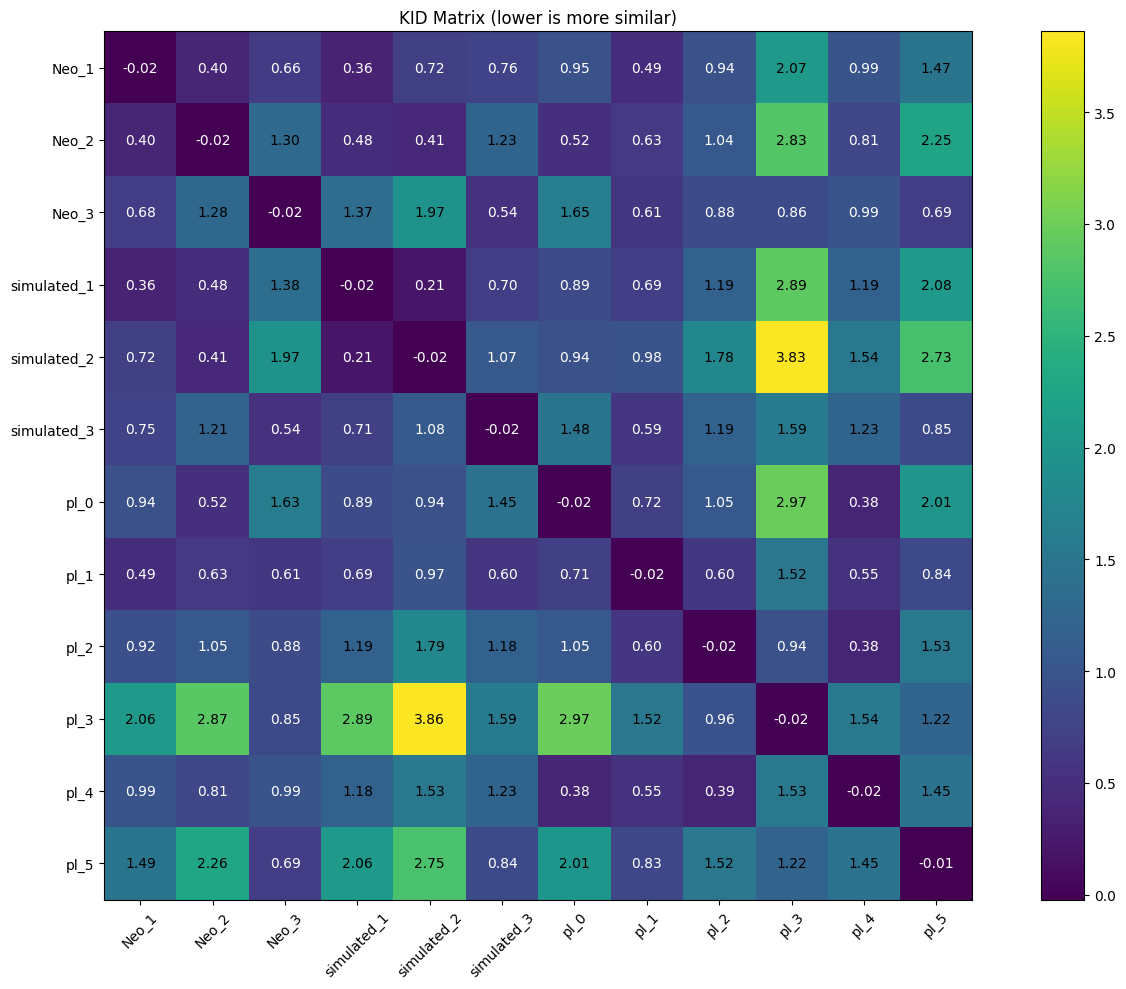

Average KID against PL datasets:
  Neo_1                 1.1516
  Neo_2                 1.3455
  Neo_3                 0.9461
  simulated_1           1.4899
  simulated_2           1.9681
  simulated_3           1.1544
  pl_0                  1.4261
  pl_1                  0.8442
  pl_2                  0.9011
  pl_3                  1.6423
  pl_4                  0.8595
  pl_5                  1.4060


In [12]:
plot_matrix(kid_results, dataset_names, title="KID Matrix (lower is more similar)")

avg_kid_scores = {}
for i, name_i in enumerate(datasets.keys()):
    avg_kid_scores[name_i] = np.mean([
        kid_results[i, j]
        for j, name_j in enumerate(datasets.keys())
        if name_j.startswith("pl") and j != i
    ])

print("Average KID against PL datasets:")
for name, score in avg_kid_scores.items():
    print(f"  {name:<20s}  {score:.4f}")

## 8. Multi-Scale Inception Distance (MSID)

MSID extends FID by comparing feature distributions at multiple scales. Lower values indicate greater similarity.

In [13]:
msid_metric = MSID()

msid_results = np.zeros((nb_datasets, nb_datasets))
for i, (name_i, emb_i) in enumerate(datasets.items()):
    for j, (name_j, emb_j) in enumerate(datasets.items()):
        x_feats = torch.from_numpy(np.array(emb_i)).float()
        y_feats = torch.from_numpy(np.array(emb_j)).float()
        msid_results[i, j] = msid_metric(x_feats, y_feats).item()

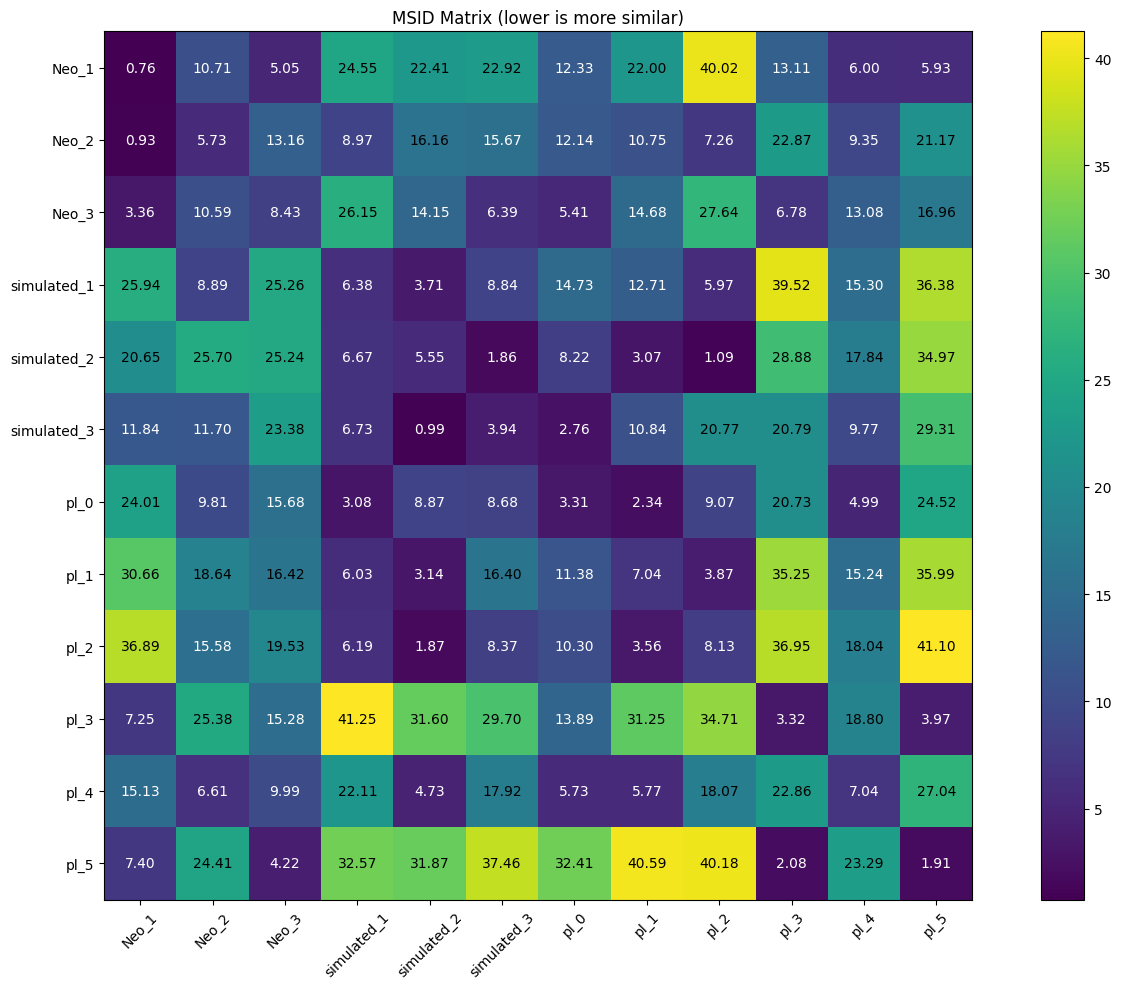

Mean MSID against Pléiades datasets:
  Neo_1                 16.5657
  Neo_2                 13.9226
  Neo_3                 14.0907
  simulated_1           20.7675
  simulated_2           15.6769
  simulated_3           15.7073
  pl_0                  12.3324
  pl_1                  20.3444
  pl_2                  21.9927
  pl_3                  20.5229
  pl_4                  15.8934
  pl_5                  27.7074


In [14]:
plot_matrix(msid_results, dataset_names, title="MSID Matrix (lower is more similar)")

mean_msid_scores = compute_mean_scores(msid_results, dataset_names, prefix="pl")
print("Mean MSID against Pléiades datasets:")
for name, score in mean_msid_scores.items():
    print(f"  {name:<20s}  {score:.4f}")

## 9. Inception Score (IS)

IS measures both quality and diversity of generated images. Higher values are better.

In [15]:
is_metric = IS()

is_results = np.zeros((nb_datasets, nb_datasets))
for i, (name_i, emb_i) in enumerate(datasets.items()):
    for j, (name_j, emb_j) in enumerate(datasets.items()):
        x_feats = torch.from_numpy(np.array(emb_i)).float()
        y_feats = torch.from_numpy(np.array(emb_j)).float()
        is_results[i, j] = is_metric(x_feats, y_feats).item()

/home/thomas/miniconda3/envs/sam3_env/lib/python3.12/site-packages/piq/isc.py:45: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probas = F.softmax(features)


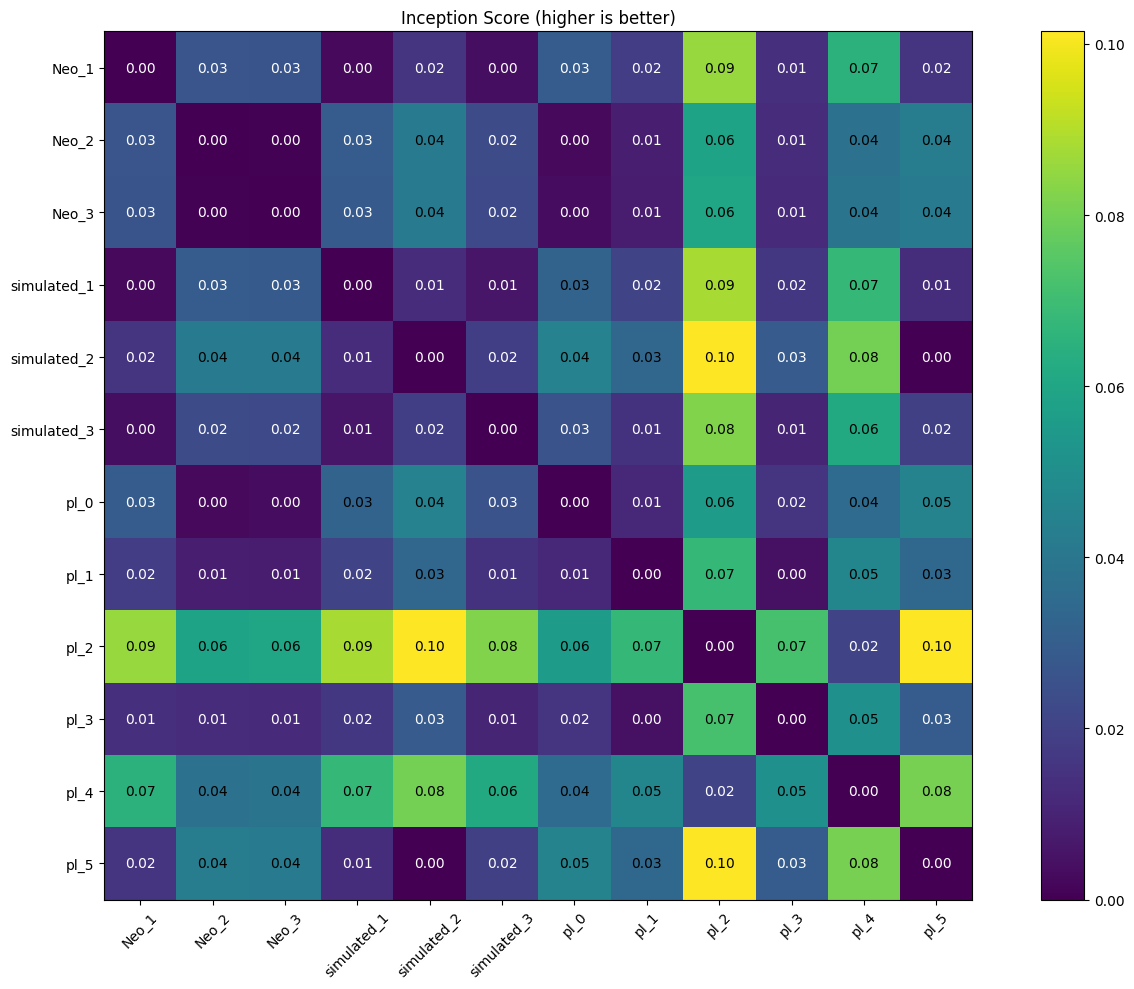

Mean IS against Pléiades datasets:
  Neo_1                 0.0381
  Neo_2                 0.0273
  Neo_3                 0.0273
  simulated_1           0.0397
  simulated_2           0.0483
  simulated_3           0.0358
  pl_0                  0.0328
  pl_1                  0.0328
  pl_2                  0.0636
  pl_3                  0.0345
  pl_4                  0.0470
  pl_5                  0.0582


In [16]:
plot_matrix(is_results, dataset_names, title="Inception Score (higher is better)")

mean_is_scores = compute_mean_scores(is_results, dataset_names, prefix="pl")
print("Mean IS against Pléiades datasets:")
for name, score in mean_is_scores.items():
    print(f"  {name:<20s}  {score:.4f}")

## 10. Cosine Similarity

Average pairwise cosine similarity between tile embeddings across datasets. Higher means more similar.

In [17]:
similarity_results = np.zeros((nb_datasets, nb_datasets))
for i, (name_i, emb_i) in enumerate(datasets.items()):
    for j, (name_j, emb_j) in enumerate(datasets.items()):
        similarity_results[i, j] = np.mean(cosine_similarity(emb_i, emb_j))

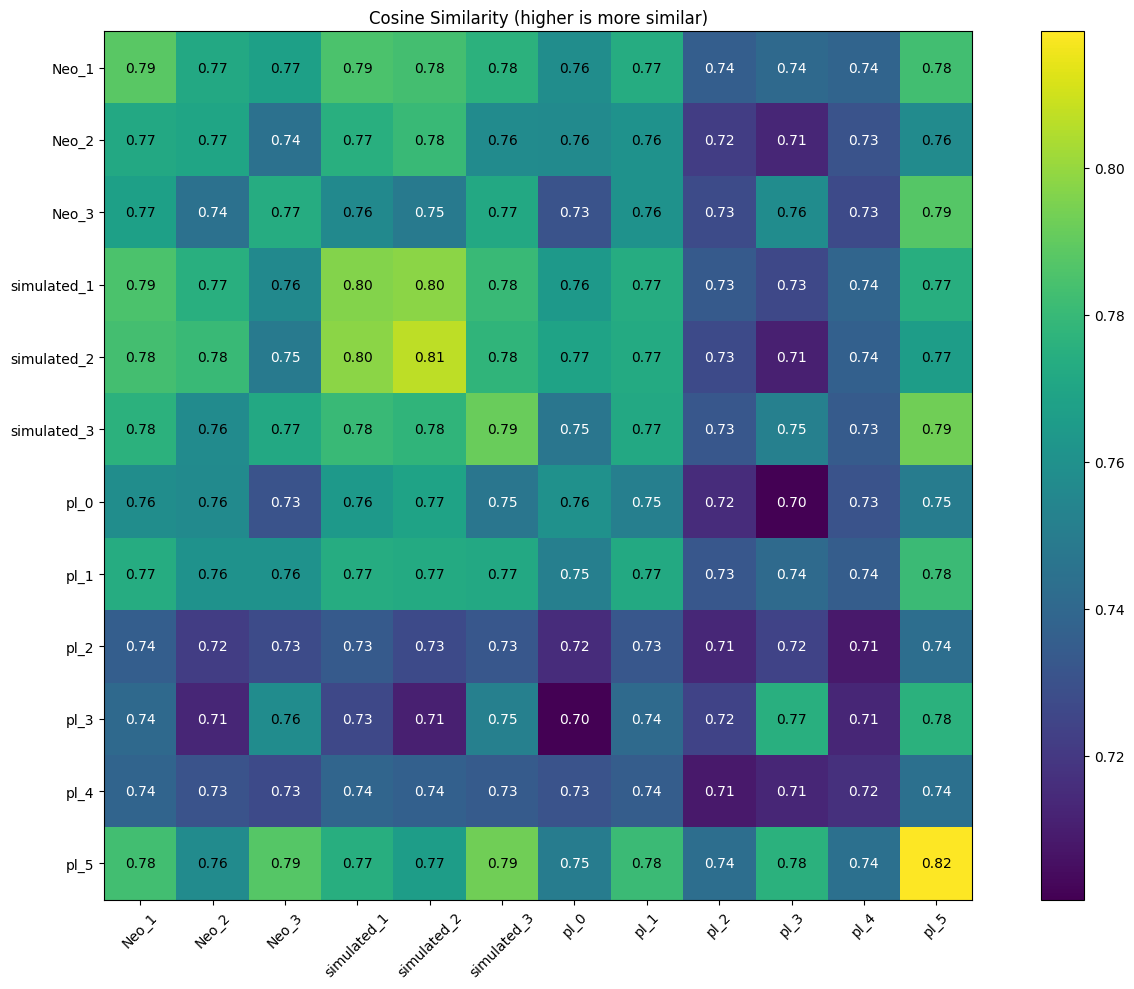

Average Cosine Similarity against Pléiades datasets:
  Neo_1                 nan
  Neo_2                 nan
  Neo_3                 nan
  simulated_1           nan
  simulated_2           nan
  simulated_3           nan
  pl_0                  nan
  pl_1                  nan
  pl_2                  nan
  pl_3                  nan
  pl_4                  nan
  pl_5                  nan


/home/thomas/miniconda3/envs/sam3_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/thomas/miniconda3/envs/sam3_env/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [18]:
plot_matrix(similarity_results, dataset_names, title="Cosine Similarity (higher is more similar)")

similarity_mean_scores = compute_mean_scores(similarity_results, dataset_names, prefix="S2")
print("Average Cosine Similarity against Pléiades datasets:")
for name, score in similarity_mean_scores.items():
    print(f"  {name:<20s}  {score:.4f}")

## 11. Euclidean Distance

Average pairwise L2 distance between tile embeddings across datasets. Lower means more similar.

In [19]:
distance_results = np.zeros((nb_datasets, nb_datasets))
for i, (name_i, emb_i) in enumerate(datasets.items()):
    for j, (name_j, emb_j) in enumerate(datasets.items()):
        distance_results[i, j] = np.mean(euclidean_distances(emb_i, emb_j))

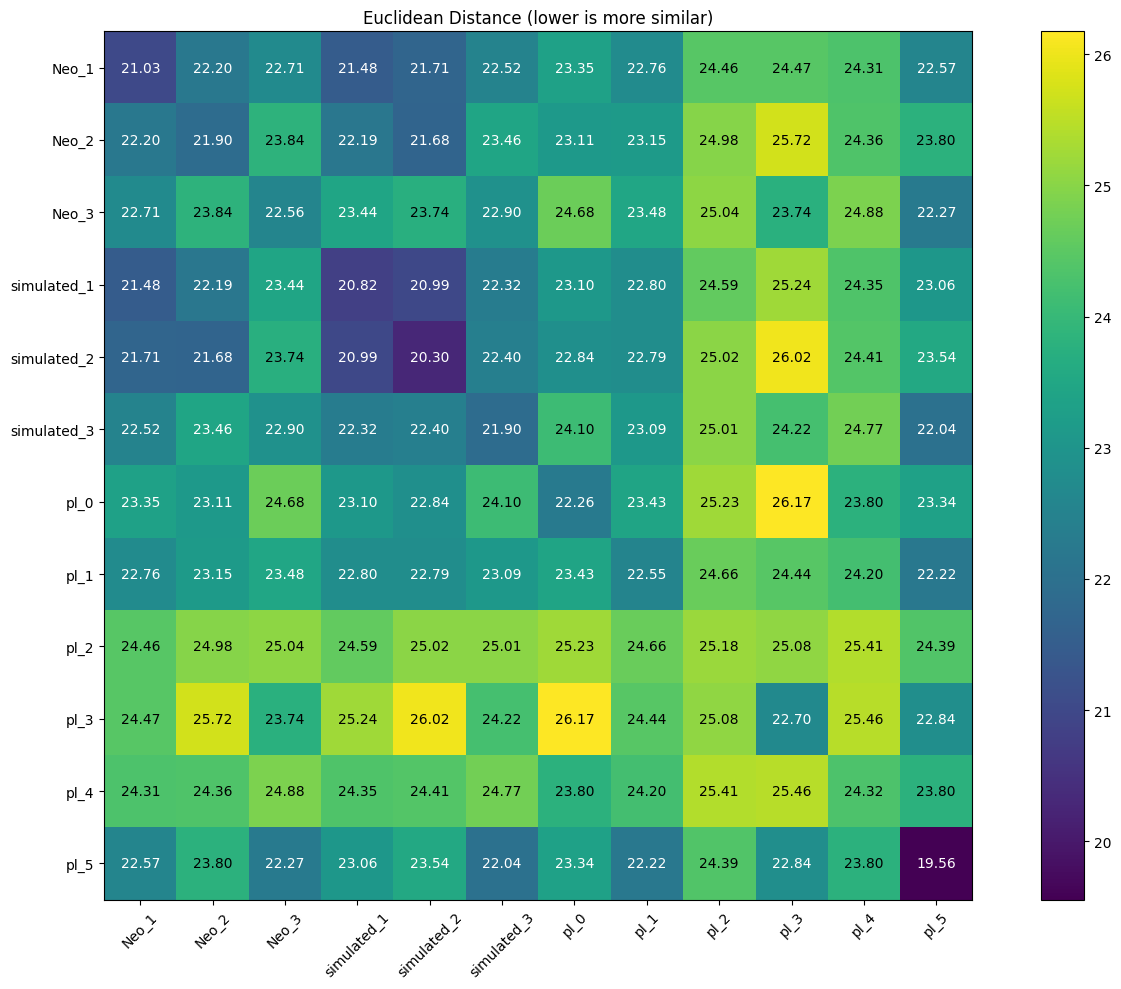

Average Euclidean Distance against Pléiades datasets:
  Neo_1                 23.6536
  Neo_2                 24.1882
  Neo_3                 24.0146
  simulated_1           23.8566
  simulated_2           24.1028
  simulated_3           23.8712
  pl_0                  24.3956
  pl_1                  23.7915
  pl_2                  24.9538
  pl_3                  24.7974
  pl_4                  24.5332
  pl_5                  23.3166


In [20]:
plot_matrix(distance_results, dataset_names, title="Euclidean Distance (lower is more similar)")

distance_mean_scores = compute_mean_scores(distance_results, dataset_names, prefix="pl")
print("Average Euclidean Distance against Pléiades datasets:")
for name, score in distance_mean_scores.items():
    print(f"  {name:<20s}  {score:.4f}")

## 12. UMAP Projection of SatDINO Embeddings

UMAP projects the high-dimensional SatDINO embeddings (768-d) into 2D for visual inspection.  
Tight clustering of *Simulated PHR* with *Real PHR* indicates successful domain transfer.  
*Parameters:* n_neighbors=15, min_dist=0.1, metric=cosine.

In [21]:
# Aggregate features and assign semantic labels
all_features = []
labels = []

for key, emb in datasets.items():
    if key.startswith("Neo"):
        plot_label = "Real Neo (Baseline)"
    elif key.startswith("simulated"):
        plot_label = "Simulated PHR (Ours)"
    elif key.startswith("pl_"):
        plot_label = "Real PHR (Target)"
    else:
        print(f"Skipping unmapped key: {key}")
        continue

    if torch.is_tensor(emb):
        emb = emb.cpu().numpy()

    all_features.append(emb)
    labels.extend([plot_label] * emb.shape[0])

all_features = np.vstack(all_features)
labels = np.array(labels)

print(f"Aggregated {all_features.shape[0]} samples across {len(set(labels))} domains.")
print("Computing UMAP projection…")
reducer    = umap.UMAP(n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST,
                       metric=UMAP_METRIC, random_state=UMAP_RANDOM_STATE)
projection = reducer.fit_transform(all_features)

Aggregated 8400 samples across 3 domains.
Computing UMAP projection…


/home/thomas/miniconda3/envs/sam3_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


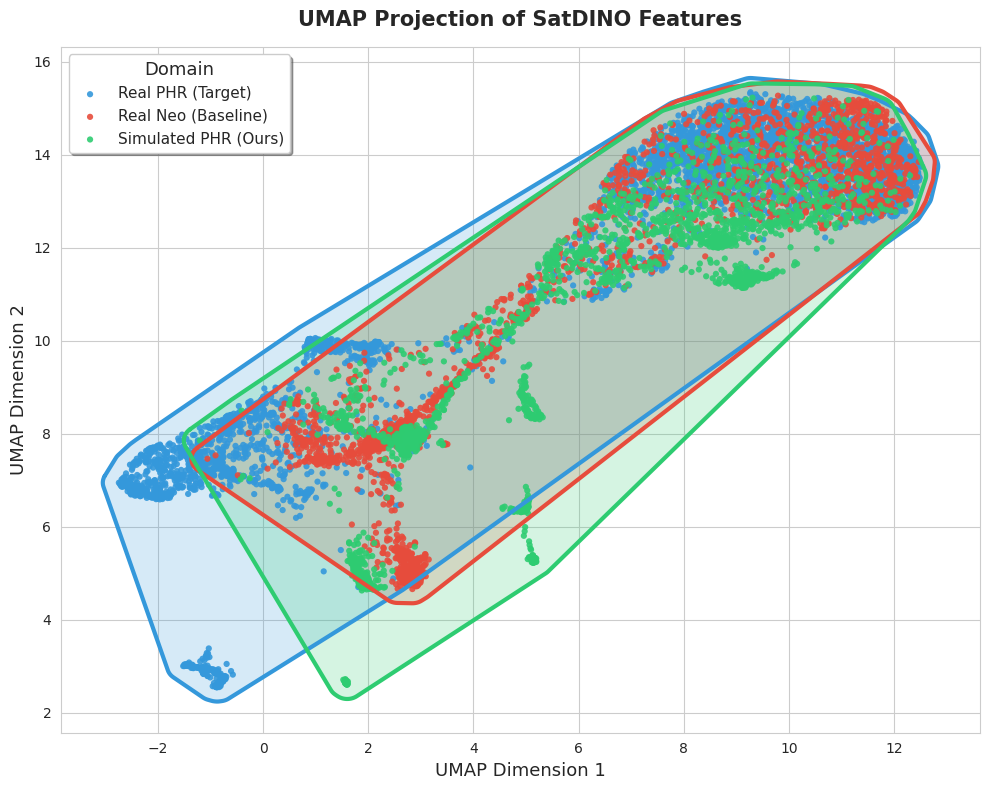

In [22]:
sns.set_style("whitegrid")
fig_umap, ax = plt.subplots(figsize=(10, 8))

x_range = projection[:, 0].max() - projection[:, 0].min()
y_range = projection[:, 1].max() - projection[:, 1].min()
buffer_distance = max(x_range, y_range) * 0.02

# Phase 1 — filled convex hull boundaries
for i, domain in enumerate(DRAWING_ORDER):
    idx    = np.where(labels == domain)[0]
    points = projection[idx]
    if len(points) >= 4:
        hull        = ConvexHull(points)
        poly        = Polygon(points[hull.vertices])
        smooth_poly = poly.buffer(buffer_distance, join_style=1, cap_style=1)
        x_new, y_new = smooth_poly.exterior.xy
        ax.fill(x_new, y_new, color=COLOR_PALETTE[domain], alpha=0.2, zorder=1 + i)
        ax.plot(x_new, y_new, color=COLOR_PALETTE[domain], linewidth=3, zorder=20 + i)

# Phase 2 — scatter points
for i, domain in enumerate(DRAWING_ORDER):
    idx    = np.where(labels == domain)[0]
    points = projection[idx]
    ax.scatter(points[:, 0], points[:, 1], c=COLOR_PALETTE[domain],
               label=domain, alpha=0.9, s=20, edgecolors="none", zorder=10 + i)

ax.set_title("UMAP Projection of SatDINO Features", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("UMAP Dimension 1", fontsize=13)
ax.set_ylabel("UMAP Dimension 2", fontsize=13)
ax.legend(title="Domain", title_fontsize=13, fontsize=11, loc="best", frameon=True, shadow=True)

plt.tight_layout()
plt.show()

## 13. Interactive UMAP Explorer

Click any point to inspect the corresponding tile image and its RGB statistics.

In [23]:
fig_widget = go.FigureWidget()

x_range = projection[:, 0].max() - projection[:, 0].min()
y_range = projection[:, 1].max() - projection[:, 1].min()
buffer_distance = max(x_range, y_range) * 0.02

# Phase 1 — background polygons
for domain in DRAWING_ORDER:
    idx    = np.where(labels == domain)[0]
    points = projection[idx]
    if len(points) >= 4:
        hull        = ConvexHull(points)
        poly        = Polygon(points[hull.vertices])
        smooth_poly = poly.buffer(buffer_distance, join_style=1, cap_style=1)
        x_new, y_new = smooth_poly.exterior.xy
        fig_widget.add_trace(go.Scatter(
            x=list(x_new), y=list(y_new),
            mode="lines", fill="toself",
            fillcolor=hex_to_rgba(COLOR_PALETTE[domain], 0.2),
            line=dict(color=COLOR_PALETTE[domain], width=3),
            name=domain + " Boundary",
            hoverinfo="skip", showlegend=False,
        ))

# Phase 2 — scatter points
for domain in DRAWING_ORDER:
    idx = np.where(labels == domain)[0]
    fig_widget.add_trace(go.Scatter(
        x=projection[idx, 0], y=projection[idx, 1],
        mode="markers", name=domain,
        marker=dict(color=COLOR_PALETTE[domain], size=6, opacity=0.8),
        customdata=idx,
    ))

fig_widget.update_layout(
    title="Interactive UMAP: Click a dot to view the tile",
    xaxis_title="UMAP Dimension 1",
    yaxis_title="UMAP Dimension 2",
    width=800, height=650,
    template="plotly_white",
    hovermode="closest",
)

# Output panel
out = widgets.Output(layout=widgets.Layout(
    width="450px", height="580px",
    border="1px solid #ccc",
    margin="50px 0 0 20px",
))
with out:
    print("Click any point on the UMAP to load the corresponding tile here.")

# Click callback
def on_click_point(trace, points, selector):
    if not points.point_inds:
        return
    global_idx = trace.customdata[points.point_inds[0]]
    out.clear_output(wait=True)
    with out:
        try:
            tile_image = all_sampled_tiles[global_idx]

            r_min, r_max = np.min(tile_image[:, :, 0]), np.max(tile_image[:, :, 0])
            g_min, g_max = np.min(tile_image[:, :, 1]), np.max(tile_image[:, :, 1])
            b_min, b_max = np.min(tile_image[:, :, 2]), np.max(tile_image[:, :, 2])
            print(f"RGB Pixel Stats — Index: {global_idx}")
            print(f"  Red   | Min: {r_min:8.2f}, Max: {r_max:8.2f}")
            print(f"  Green | Min: {g_min:8.2f}, Max: {g_max:8.2f}")
            print(f"  Blue  | Min: {b_min:8.2f}, Max: {b_max:8.2f}")

            fig_img, ax_img = plt.subplots(figsize=(4, 4))
            ax_img.imshow(tile_image)
            ax_img.axis("off")
            ax_img.set_title(f"{labels[global_idx]}\nIndex: {global_idx}")
            plt.show()

            open_btn = widgets.Button(description="Open in PC Viewer",
                                      button_style="info", icon="external-link")
            def open_in_os(b):
                img_array = tile_image
                if img_array.dtype != np.uint8:
                    img_array = (img_array * 255).astype(np.uint8) if img_array.max() <= 1.0 else img_array.astype(np.uint8)
                Image.fromarray(img_array).show()
            open_btn.on_click(open_in_os)
            display(open_btn)

        except Exception as e:
            print(f"Error loading index {global_idx}: {e}")

for trace in fig_widget.data:
    if trace.mode == "markers":
        trace.on_click(on_click_point)

display(widgets.HBox([fig_widget, out]))

    'data': [{'fill': 'toself',
              'fillcolor': 'rgba(52,152,219,0.2)…